<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_10_SBIBM_Hybrid_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 10 — A high-precision hNPE–hNDE benchmark on sbibm

Exercises 5–9 established the hybrid constructions on controlled examples. This exercise is an independent benchmark implementation: none of their algorithms or helper functions is modified.

Version 2 implements the predeclared “winning strategy”:

- a correctly mixed neural spline flow, with learned LU mixing after every coupling transform;
- a small all-data NSF baseline matching the architecture scale used by the published NPE;
- genuine fivefold cross-fitting, so every simulation trains a ratio exactly once and a flow four times;
- one large, four-member posterior correction ensemble in every fold;
- an equally large, four-member hNDE likelihood-ratio ensemble in every fold;
- plateau learning-rate schedules, fresh checkpoints, and diagnostics selected without reference posterior samples;
- full C2ST comparisons for the NPE reference, hNPE, hNDE, and the dual consensus;
- explicit campaigns for both Two Moons and SLCP.

The simulator budget remains exactly 100,000 unique prior-predictive pairs per task. Cross-fitting and ensembling spend computation, not additional simulator calls.


In [1]:
## ============================================================================
# Google Colab setup — safe to re-run and a no-op off Colab.
# ============================================================================
import os, sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = True


def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    # This backward-compatible working directory preserves models from Exercises 4--9.
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    # Colab already provides PyTorch, NumPy, SciPy, pandas, and scikit-learn.
    # Installing sbibm without its historical algorithm dependencies avoids
    # downgrading the modern Colab environment; only the task/metric dependencies
    # used below are added explicitly. Version 1.1.0 is the latest official
    # sbibm release and includes the corrected Gaussian Mixture simulator.
    run(sys.executable, "-m", "pip", "install", "-q", "nflows", "pyro-ppl")
    run(
        sys.executable, "-m", "pip", "install", "-q", "--no-deps",
        "sbibm==1.1.0",
    )
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
else:
    for candidate in [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
    ]:
        if (candidate / "utils_benchmark.py").exists():
            sys.path.insert(0, str(candidate.resolve()))
            break

print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


In [2]:
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sbibm
import torch
from IPython.display import display

from utils_benchmark import (
    PAPER_ALGORITHMS,
    benchmark_ratio_tail_diagnostics,
    best_published_targets,
    compare_with_paper,
    crossfit_coverage_table,
    draw_hybrid_posterior,
    evaluate_observation_suite,
    evaluate_posterior_samples,
    load_or_simulate_bank,
    load_paper_results,
    posterior_predictive_diagnostics,
    simulation_based_calibration_diagnostics,
    summarize_our_results,
    summarize_paper_results,
    task_recommendation_table,
    train_hybrid_benchmark_model,
    train_official_style_nsf_baseline,
    training_diagnostics,
)
from utils_plotting import export_standalone_figure_script

SEED = 23102026
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("sbibm version:", sbibm.__version__)
print("Using device:", device)


sbibm version: 1.1.0
Using device: cuda


## 1. What is in the benchmark?

The paper defines ten tasks from eight simulator families. This campaign focuses on two continuous tasks for which both hybrid paths are well defined:

- **Two Moons** has a curved, multimodal two-dimensional posterior and directly exposes whether a flow mixes both parameter coordinates.
- **SLCP** has five parameters, eight observables, and a four-mode posterior. It is a substantially harder test of both the conditional posterior and the generative hNDE route.

The remaining tasks stay in the recommendation table for later campaigns. The discrete and ODE tasks require additional modeling choices and are not silently forced through a continuous hNDE.


In [3]:
recommendations = task_recommendation_table()
display(
    recommendations[
        [
            "task", "dim_parameters", "dim_data", "data_type",
            "recommended_method", "colab_status", "reason",
        ]
    ].style.hide(axis="index")
)


task,dim_parameters,dim_data,data_type,recommended_method,colab_status,reason
gaussian_linear,10,10,continuous,dual hNPE--hNDE,ready,A normalization and scaling control; the posterior is nearly solved.
gaussian_linear_uniform,10,10,"continuous, bounded parameters",dual hNPE--hNDE,ready,Tests exact bounded support through the parameter logit transform.
gaussian_mixture,2,2,continuous mixture,dual hNPE--hNDE,ready,A compact heavy-tail test; corrected v1.1 benchmark results are used.
two_moons,2,2,"continuous, multimodal",dual hNPE--hNDE,primary target,The paper's diagnostic example has curved modes and clear headroom.
slcp,5,8,"continuous, four-mode posterior",dual hNPE--hNDE,stretch target,The best published mean C2ST at 100k is still far from 0.5.
slcp_distractors,5,100,continuous with 92 distractors,hNPE; optional dual,expensive,hNPE avoids making a 100-dimensional observation flow the bottleneck.
bernoulli_glm,10,10,discrete-derived sufficient statistics,hNPE,ready,A conditional posterior can use the summaries directly; a continuous hNDE reference is not an exact probability-mass model.
bernoulli_glm_raw,10,100,binary,hNPE,expensive,The raw observation is discrete and 100-dimensional.
sir,2,10,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia; hNDE would need a discrete or dequantized reference model.
lotka_volterra,4,20,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia and is costly.


## 2. The two hybrid factorizations and the cross-fit

One prior-predictive bank is sampled,

$$
(\theta_i,x_i)\sim\pi(\theta)p(x\mid\theta).
$$

For fold $k$, four fifths train the posterior flow
$q_{\phi,k}(\theta\mid x)$ and the held-out fifth trains

$$
r_{{\rm P},k}(\theta,x)
=
\frac{p(\theta\mid x)}
{(1-\epsilon)q_{\phi,k}(\theta\mid x)+\epsilon\pi(\theta)}.
$$

The independent likelihood route trains a conditional flow and a
residual correction,

$$
q_{\eta,k}(x\mid\theta)\approx p(x\mid\theta),\qquad
c_k(x,\theta)=\frac{p(x\mid\theta)}
{q_{\eta,k}(x\mid\theta)}.
$$

Its normalized likelihood is

$$
\widehat L_k(x;\theta)
=
q_{\eta,k}(x\mid\theta)
\frac{\widehat c_k(x,\theta)}
{\widehat Z_{{\rm C},k}(\theta)}.
$$

Positive and negative classifier rows share either $x_i$ (hNPE) or
$\theta_i$ (hNDE). The simulator indices are split before the class rows
are constructed, so paired rows cannot leak across training and
validation.


## 3. What has to be beaten?

The paper evaluates 10,000 inferred posterior samples against 10,000 reference samples with a z-scored, five-fold neural classifier two-sample test. C2ST $=0.5$ is ideal and lower is better. Results are averaged over ten fixed observations, with simulation budgets of $10^3$, $10^4$, and $10^5$ **per trained inference model**.

The official Gaussian Mixture simulator had a bug that was corrected in `sbibm` v1.1.0. Exercise 10 uses the official rerun table for that task and the manuscript table for the other nine tasks.


In [4]:
paper_results = load_paper_results(corrected_gaussian_mixture=True)
targets_100k = best_published_targets(paper_results, num_simulations=100_000)
display(
    targets_100k[
        ["task", "algorithm", "mean", "ci95"]
    ].rename(
        columns={
            "algorithm": "best published algorithm",
            "mean": "mean C2ST",
            "ci95": "95% CI",
        }
    ).style.format({"mean C2ST": "{:.4f}", "95% CI": "{:.4f}"}).hide(axis="index")
)


task,best published algorithm,mean C2ST,95% CI
bernoulli_glm,SNLE,0.5218,0.0078
bernoulli_glm_raw,SNRE,0.5525,0.0091
gaussian_linear,NPE,0.5060,0.0025
gaussian_linear_uniform,NLE,0.5065,0.0027
gaussian_mixture,SNRE,0.5310,0.0110
lotka_volterra,SNLE,0.6951,0.0635
sir,SNRE,0.5472,0.0162
slcp,SNLE,0.5781,0.0182
slcp_distractors,SNRE,0.7662,0.0318
two_moons,SNPE,0.5298,0.0159


## 4. Choose the campaign

The profiles control computation but never change the simulator accounting. The paper and challenge profiles use five complementary folds and four large ratio networks per fold, for both hNPE and hNDE.

Run the notebook first with Two Moons. Then change only TASK_NAME to SLCP and rerun; the final campaign cell combines the two saved v2 result files.


In [5]:
PROFILE = "challenge"  # "quick", "paper", or "challenge"
TASK_NAME = "slcp"
BENCHMARK_TASKS = ("two_moons", "slcp")
LOAD_IF_AVAILABLE = True
RUN_SBC = True
RUN_POSTERIOR_PREDICTIVE = False  # Extra simulator calls.

if TASK_NAME not in BENCHMARK_TASKS:
    raise ValueError(f"TASK_NAME must be one of {BENCHMARK_TASKS}.")

PROFILES = {
    "quick": {
        "num_simulations": 10_000,
        "num_folds": 2,
        "ensemble_size": 2,
        "flow_epochs": 25,
        "baseline_epochs": 25,
        "ratio_epochs": 35,
        "n_proposal": 60_000,
        "observations": [1],
        "sbc_cases_per_fold": 8,
        "sbc_proposal": 256,
        "normalizer_contexts": 512,
        "normalizer_reference": 32,
    },
    "paper": {
        "num_simulations": 100_000,
        "num_folds": 5,
        "ensemble_size": 4,
        "flow_epochs": 70,
        "baseline_epochs": 70,
        "ratio_epochs": 90,
        "n_proposal": 300_000,
        "observations": list(range(1, 11)),
        "sbc_cases_per_fold": 24,
        "sbc_proposal": 512,
        "normalizer_contexts": 2_048,
        "normalizer_reference": 64,
    },
    "challenge": {
        "num_simulations": 100_000,
        "num_folds": 5,
        "ensemble_size": 4,
        "flow_epochs": 90,
        "baseline_epochs": 90,
        "ratio_epochs": 120,
        "n_proposal": 500_000,
        "observations": list(range(1, 11)),
        "sbc_cases_per_fold": 32,
        "sbc_proposal": 768,
        "normalizer_contexts": 2_048,
        "normalizer_reference": 64,
    },
}
campaign = PROFILES[PROFILE]
NUM_SIMULATIONS = campaign["num_simulations"]
N_CROSSFIT_FOLDS = campaign["num_folds"]
RATIO_ENSEMBLE_SIZE = campaign["ensemble_size"]
N_PROPOSAL = campaign["n_proposal"]
OBSERVATIONS = campaign["observations"]
N_POSTERIOR_SAMPLES = 10_000
DEFENSIVE_EPSILON = 0.02
SPLIT_SEED = SEED + 17
TRAIN_HNDE = True
HEADLINE_METHOD = "hNPE"

FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 8,
    "hidden_features": 256,
    "hidden_layers": 3,
    "spline_num_bins": 16,
    "spline_tail_bound": 5.0,
    "dropout_probability": 0.0,
}
FLOW_TRAINING_CONFIG = {
    "batch_size": 1024,
    "n_epochs": campaign["flow_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 4,
    "min_learning_rate": 1.0e-6,
    "validation_fraction": 0.1,
    "patience": 18,
    "gradient_clip": 5.0,
}
BASELINE_MODEL_CONFIG = {
    "n_coupling_layers": 5,
    "hidden_features": 50,
    "hidden_layers": 2,
    "spline_num_bins": 10,
    "spline_tail_bound": 3.0,
    "dropout_probability": 0.0,
}
BASELINE_TRAINING_CONFIG = {
    **FLOW_TRAINING_CONFIG,
    "n_epochs": campaign["baseline_epochs"],
    "patience": 15,
}
RATIO_MODEL_CONFIG = {
    "hidden_features": 1024,
    "hidden_layers": 5,
    "dropout_probability": 0.0,
}
RATIO_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": campaign["ratio_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler": "plateau",
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 3,
    "min_learning_rate": 1.0e-6,
    "validation_fraction": 0.15,
    "patience": 25,
    "gradient_clip": 5.0,
}

RUN_TAG = (
    f"{PROFILE}_budget{NUM_SIMULATIONS}_lu8_k{N_CROSSFIT_FOLDS}_"
    f"ratioensemble{RATIO_ENSEMBLE_SIZE}_conditionalref_v3"
)
MODEL_DIR = Path("models_exercise10_sbibm") / TASK_NAME / RUN_TAG
CACHE_DIR = Path("dataframes_exercise10_sbibm")
RESULT_DIR = Path("exercise10_benchmark_results")
FIGURE_SCRIPT_DIR = (
    Path("exercise10_figures_scripts") / TASK_NAME / RUN_TAG
)
for directory in (MODEL_DIR, CACHE_DIR, RESULT_DIR, FIGURE_SCRIPT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "profile": PROFILE,
    "task": TASK_NAME,
    "campaign_tasks": BENCHMARK_TASKS,
    "simulator_budget": NUM_SIMULATIONS,
    "crossfit_folds": N_CROSSFIT_FOLDS,
    "ratio_members_per_fold_per_path": RATIO_ENSEMBLE_SIZE,
    "conditional_reference_hnde": TRAIN_HNDE,
    "normalizer_contexts": campaign["normalizer_contexts"],
    "normalizer_reference_per_context": campaign["normalizer_reference"],
    "headline_method": HEADLINE_METHOD,
    "run_tag": RUN_TAG,
    "observations": OBSERVATIONS,
}, indent=2))


{
  "profile": "challenge",
  "task": "slcp",
  "campaign_tasks": [
    "two_moons",
    "slcp"
  ],
  "simulator_budget": 100000,
  "crossfit_folds": 5,
  "ratio_members_per_fold_per_path": 4,
  "conditional_reference_hnde": true,
  "normalizer_contexts": 2048,
  "normalizer_reference_per_context": 64,
  "headline_method": "hNPE",
  "run_tag": "challenge_budget100000_lu8_k5_ratioensemble4_conditionalref_v3",
  "observations": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ]
}


## 5. Acquire the exact-budget simulation bank

The official prior and simulator generate one cached bank per task and budget. The same bank is reused by the all-data NSF baseline, all five hNPE folds, and all five hNDE folds. The coverage check below fails immediately unless every row has exactly one ratio role and four flow roles in the fivefold campaign.


In [6]:
try:
    task = sbibm.get_task(TASK_NAME)
except (ImportError, ModuleNotFoundError) as exc:
    raise RuntimeError(f"Could not load the official sbibm task {TASK_NAME!r}.") from exc

print(
    f"{task.name_display}: dim(theta)={task.dim_parameters}, "
    f"dim(x)={task.dim_data}, observations={task.num_observations}"
)
simulation_bank = load_or_simulate_bank(
    task,
    NUM_SIMULATIONS,
    cache_path=CACHE_DIR / f"{TASK_NAME}_prior_predictive_{NUM_SIMULATIONS}_seed{SEED}.npz",
    seed=SEED,
    chunk_size=20_000,
)
assert simulation_bank.num_simulations == NUM_SIMULATIONS
print("Unique simulator calls used for every neural object:", simulation_bank.num_simulations)

coverage = crossfit_coverage_table(
    simulation_bank,
    n_folds=N_CROSSFIT_FOLDS,
    split_seed=SPLIT_SEED,
)
display(coverage.style.hide(axis="index"))


SLCP: dim(theta)=5, dim(x)=8, observations=10
Loaded 100,000 simulations from dataframes_exercise10_sbibm/slcp_prior_predictive_100000_seed23102026.npz
Unique simulator calls used for every neural object: 100000


fold,flow_rows,ratio_rows,overlap_rows,ratio_coverage_min,ratio_coverage_max,flow_coverage_min,flow_coverage_max
0,80000,20000,0,1,1,4,4
1,80000,20000,0,1,1,4,4
2,80000,20000,0,1,1,4,4
3,80000,20000,0,1,1,4,4
4,80000,20000,0,1,1,4,4


## 6. Train the all-data NSF and fivefold dual model

Each fold trains two high-capacity conditional flows:

- $q_{\phi,k}(\theta\mid x)$ for the posterior proposal;
- $q_{\eta,k}(x\mid\theta)$ for the likelihood reference.

The held-out fold trains paired residual classifiers for both routes.
A small regressor estimates $\log Z_{{\rm C},k}(\theta)$ from
conditional-flow samples only, so no simulator calls are added. The v3
checkpoint tag prevents any unconditional-reference v2 model from being
loaded accidentally.


In [7]:
baseline_model = train_official_style_nsf_baseline(
    task,
    simulation_bank,
    checkpoint=MODEL_DIR / "all_data_official_style_nsf.pt",
    model_config=BASELINE_MODEL_CONFIG,
    training_config=BASELINE_TRAINING_CONFIG,
    device=device,
    seed=SEED + 5_000,
    load_if_available=LOAD_IF_AVAILABLE,
)

hybrid_models = []
for fold in range(N_CROSSFIT_FOLDS):
    print("\n" + "=" * 88)
    print(f"TRAINING CROSSFIT FOLD {fold + 1}/{N_CROSSFIT_FOLDS}")
    print("=" * 88)
    hybrid_models.append(
        train_hybrid_benchmark_model(
            task,
            simulation_bank,
            model_dir=MODEL_DIR,
            flow_model_config=FLOW_MODEL_CONFIG,
            flow_training_config=FLOW_TRAINING_CONFIG,
            ratio_model_config=RATIO_MODEL_CONFIG,
            ratio_training_config=RATIO_TRAINING_CONFIG,
            device=device,
            seed=SEED + 100_000 * fold,
            split_seed=SPLIT_SEED,
            ensemble_size=RATIO_ENSEMBLE_SIZE,
            defensive_epsilon=DEFENSIVE_EPSILON,
            fold=fold,
            n_folds=N_CROSSFIT_FOLDS,
            train_hnde=TRAIN_HNDE,
            load_if_available=LOAD_IF_AVAILABLE,
            retrain_outliers=True,
            normalizer_contexts=campaign["normalizer_contexts"],
            normalizer_reference_per_context=campaign["normalizer_reference"],
        )
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(
    f"Trained the all-data baseline and {len(hybrid_models)} hybrid folds; "
    f"unique simulator calls remain {NUM_SIMULATIONS:,}."
)


Training conditional LU-mixed spline flow on 90,000 rows
  epoch 001/90: lr=1.000e-03, train=6.6573, validation=6.0934
  epoch 002/90: lr=1.000e-03, train=5.0392, validation=4.2221
  epoch 003/90: lr=1.000e-03, train=3.7369, validation=3.4727
  epoch 004/90: lr=1.000e-03, train=3.2317, validation=3.0848
  epoch 005/90: lr=1.000e-03, train=2.9785, validation=2.8896
  epoch 006/90: lr=1.000e-03, train=2.8099, validation=2.8300
  epoch 007/90: lr=1.000e-03, train=2.6891, validation=2.6456
  epoch 008/90: lr=1.000e-03, train=2.6114, validation=2.5841
  epoch 009/90: lr=1.000e-03, train=2.5332, validation=2.5458
  epoch 010/90: lr=1.000e-03, train=2.4826, validation=2.4913
  epoch 011/90: lr=1.000e-03, train=2.4297, validation=2.4617
  epoch 012/90: lr=1.000e-03, train=2.3960, validation=2.4539
  epoch 013/90: lr=1.000e-03, train=2.3573, validation=2.3744
  epoch 014/90: lr=1.000e-03, train=2.3020, validation=2.2695
  epoch 015/90: lr=1.000e-03, train=2.2474, validation=2.4649
  epoch 016/9

/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2259.)
  outputs, _ = torch.triangular_solve(



Ratio ensemble member 1/4
Training balanced ratio classifier on 20,000 rows per class with paired_groups validation
  epoch 01/120: lr=1.000e-03, train=0.6938, validation=0.6935
  epoch 02/120: lr=1.000e-03, train=0.6937, validation=0.6931
  epoch 03/120: lr=1.000e-03, train=0.6933, validation=0.6931
  epoch 04/120: lr=1.000e-03, train=0.6932, validation=0.6936
  epoch 05/120: lr=1.000e-03, train=0.6932, validation=0.6929
  epoch 06/120: lr=1.000e-03, train=0.6931, validation=0.6931
  epoch 07/120: lr=1.000e-03, train=0.6931, validation=0.6929
  epoch 08/120: lr=1.000e-03, train=0.6929, validation=0.6933
  epoch 09/120: lr=1.000e-03, train=0.6929, validation=0.6928
  epoch 10/120: lr=1.000e-03, train=0.6928, validation=0.6927
  epoch 11/120: lr=1.000e-03, train=0.6926, validation=0.6924
  epoch 12/120: lr=1.000e-03, train=0.6924, validation=0.6938
  epoch 13/120: lr=1.000e-03, train=0.6926, validation=0.6938
  epoch 14/120: lr=1.000e-03, train=0.6922, validation=0.6920
  epoch 15/120:

Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_conditionalref_v3/training_histories_conditionalref_v3.py


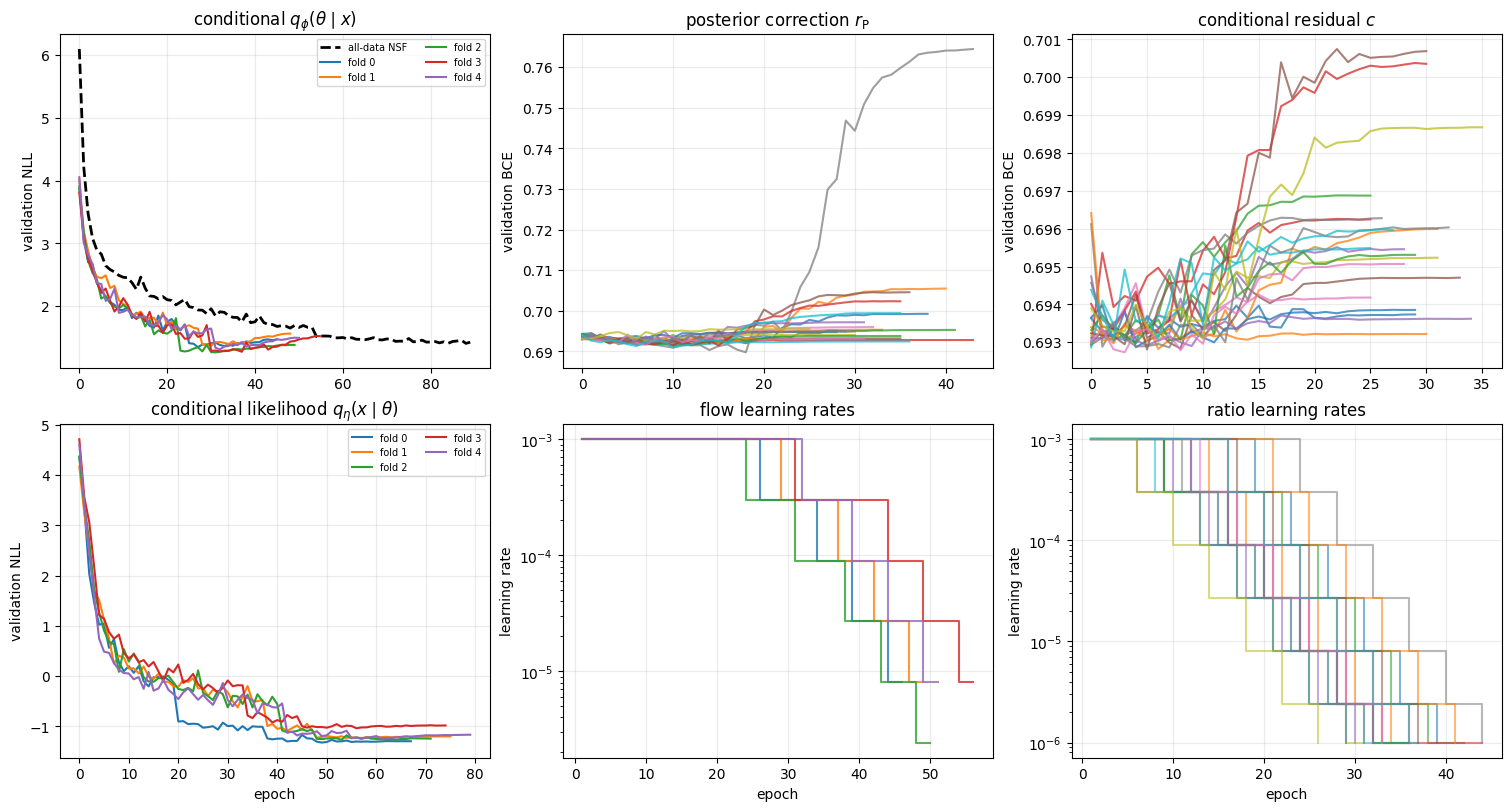

In [8]:
def export_exercise10_figure(fig, script_name):
    return export_standalone_figure_script(
        fig,
        script_name=script_name,
        output_dir=FIGURE_SCRIPT_DIR,
    )


fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes[0, 0].plot(
    baseline_model.q_phi.get("history", {}).get("validation", []),
    color="black", ls="--", lw=2, label="all-data NSF",
)
for model in hybrid_models:
    fold_label = f"fold {model.fold}"
    q_phi_history = model.q_phi.get("history", {})
    axes[0, 0].plot(q_phi_history.get("validation", []), label=fold_label)
    axes[1, 1].step(
        np.arange(1, len(q_phi_history.get("learning_rate", [])) + 1),
        q_phi_history.get("learning_rate", []),
        where="post", alpha=0.8,
    )
    for member, pack in enumerate(model.r_p_ensemble):
        history = pack.get("history", {})
        axes[0, 1].plot(
            history.get("validation", []),
            alpha=0.75,
            label=f"{fold_label}, member {member}",
        )
        axes[1, 2].step(
            np.arange(1, len(history.get("learning_rate", [])) + 1),
            history.get("learning_rate", []),
            where="post", alpha=0.55,
        )
    if model.has_hnde:
        q_eta_history = model.q_eta.get("history", {})
        axes[1, 0].plot(q_eta_history.get("validation", []), label=fold_label)
        for member, pack in enumerate(model.r_l_ensemble):
            axes[0, 2].plot(
                pack.get("history", {}).get("validation", []),
                alpha=0.75,
                label=f"{fold_label}, member {member}",
            )

axes[0, 0].set(title=r"conditional $q_\phi(\theta\mid x)$", ylabel="validation NLL")
axes[1, 0].set(title=r"conditional likelihood $q_\eta(x\mid\theta)$", xlabel="epoch", ylabel="validation NLL")
axes[0, 1].set(title=r"posterior correction $r_{\rm P}$", ylabel="validation BCE")
axes[0, 2].set(title=r"conditional residual $c$", ylabel="validation BCE")
axes[1, 1].set(title="flow learning rates", xlabel="epoch", ylabel="learning rate", yscale="log")
axes[1, 2].set(title="ratio learning rates", xlabel="epoch", ylabel="learning rate", yscale="log")
for ax in axes.flat:
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=7, ncol=2)
axes[1, 0].legend(fontsize=7, ncol=2)
export_exercise10_figure(fig, "training_histories_conditionalref_v3")
plt.show()


## 7. Predeclared diagnostics before C2ST

These checks use only the simulation bank and model-generated samples:

- held-out NLL for both conditional flows;
- honest paired-group validation BCE for both residual ensembles;
- a held-out conditional-flow C2ST comparing
  $(\theta,x_{\rm sim})$ with $(\theta,x_{q_\eta})$;
- raw and corrected $Z_{\rm C}(\theta)$ over many held-out parameters;
- member-wise log-ratio tails and arithmetic-ensemble dominance;
- lightweight out-of-fold SBC;
- per-fold and per-observation ESS, maximum weight, and Pareto-$\hat k$.

None of these diagnostics uses the official reference posterior sample.


### Training-bank normalization and SBC checks


In [9]:
prebenchmark_diagnostics = training_diagnostics(
    hybrid_models,
    simulation_bank,
    max_rows_per_fold=10_000,
    seed=SEED + 600,
)
display(
    prebenchmark_diagnostics.style.format(precision=4).hide(axis="index")
)
assert set(prebenchmark_diagnostics["rP_validation_split"]) == {
    "paired_groups"
}
assert set(prebenchmark_diagnostics["rC_validation_split"]) == {
    "paired_groups"
}

ratio_tail_diagnostics = benchmark_ratio_tail_diagnostics(
    hybrid_models,
    simulation_bank,
    max_rows_per_fold=10_000,
    seed=SEED + 605,
)
display(
    ratio_tail_diagnostics.style.format(precision=4).hide(axis="index")
)

if RUN_SBC:
    sbc_diagnostics = simulation_based_calibration_diagnostics(
        hybrid_models,
        simulation_bank,
        n_cases_per_fold=campaign["sbc_cases_per_fold"],
        n_proposal=campaign["sbc_proposal"],
        seed=SEED + 610,
    )
    display(
        sbc_diagnostics.style.format(precision=4).hide(axis="index")
    )
else:
    sbc_diagnostics = None
    print("SBC diagnostics disabled by configuration.")


fold,flow_rows,ratio_rows,q_phi_heldout_nll,rP_validation_split,rP_validation_bce,E_q_rP,q_eta_heldout_nll,q_eta_c2st_accuracy,q_eta_c2st_auc,q_eta_c2st_symmetric_auc,q_eta_c2st_binomial_pvalue,q_eta_c2st_test_rows,rC_validation_split,rL_validation_bce,E_qeta_rC_corrected_mixture,raw_Z_mean,raw_Z_max_abs_error,corrected_Z_mean,corrected_Z_max_abs_error
0,80000,20000,4.2724,paired_groups,0.6922,0.9850,10.6943,0.5025,0.5073,0.5073,0.3541,6000,paired_groups,0.6929,0.9996,0.9780,0.0567,1.0006,0.0198
1,80000,20000,4.3764,paired_groups,0.6914,0.9874,10.6549,0.5112,0.5076,0.5076,0.0430,6000,paired_groups,0.6929,1.0000,0.9795,0.0492,1.0000,0.0085
2,80000,20000,4.2816,paired_groups,0.6924,0.9945,10.6330,0.5047,0.5068,0.5068,0.2388,6000,paired_groups,0.6929,0.9997,0.9849,0.0462,0.9996,0.0194
3,80000,20000,4.2266,paired_groups,0.6917,0.9888,10.4557,0.4963,0.4999,0.5001,0.7194,6000,paired_groups,0.6930,0.9998,0.9882,0.0537,0.9997,0.0167
4,80000,20000,4.2024,paired_groups,0.6919,0.9801,10.5035,0.5033,0.5077,0.5077,0.3073,6000,paired_groups,0.6929,0.9998,0.9927,0.0282,0.9998,0.0116


fold,path,member,validation_bce,log_ratio_q50,log_ratio_q95,log_ratio_q99,log_ratio_q999,log_ratio_max,mean_arithmetic_share,dominant_fraction
0,hNPE posterior residual,0,0.6920,-0.0524,0.1178,0.3457,0.7227,0.9489,0.2439,0.0833
0,hNPE posterior residual,1,0.6926,-0.0256,0.0584,0.1544,0.2918,0.4201,0.2515,0.2821
0,hNPE posterior residual,2,0.6922,-0.0176,0.1065,0.2312,0.4573,0.6504,0.2518,0.2482
0,hNPE posterior residual,3,0.6920,-0.0175,0.1840,0.4388,0.9692,1.5626,0.2528,0.3864
0,conditional hNDE residual,0,0.6930,-0.0176,0.0175,0.0407,0.0886,0.1320,0.2512,0.3124
0,conditional hNDE residual,1,0.6928,-0.0157,0.0869,0.2220,0.5414,1.4064,0.2509,0.4012
0,conditional hNDE residual,2,0.6929,-0.0397,-0.0087,0.0115,0.0492,0.1035,0.2466,0.0948
0,conditional hNDE residual,3,0.6929,-0.0254,0.0552,0.1209,0.2199,0.4054,0.2514,0.1916
1,hNPE posterior residual,0,0.6923,-0.0425,0.0443,0.1561,0.3066,0.4414,0.2440,0.0368
1,hNPE posterior residual,1,0.6917,-0.0234,0.1720,0.3656,0.5936,0.8185,0.2532,0.2948


algorithm,dimension,num_ranks,rank_mean,rank_variance,KS_uniform,KS_pvalue
NPE reference,0,160,0.4879,0.0861,0.0542,0.7149
NPE reference,1,160,0.4945,0.0774,0.0516,0.7687
NPE reference,2,160,0.4795,0.0777,0.0604,0.5820
NPE reference,3,160,0.5109,0.0754,0.0594,0.6040
NPE reference,4,160,0.4704,0.0928,0.0943,0.1091
hNPE,0,160,0.4895,0.0849,0.0520,0.7596
hNPE,1,160,0.4957,0.0759,0.0593,0.6048
hNPE,2,160,0.4802,0.0770,0.0598,0.5955
hNPE,3,160,0.5114,0.0749,0.0594,0.6028
hNPE,4,160,0.4712,0.0895,0.0829,0.2092


### First untouched observation: posterior closure

All routes are now evaluated on the first official observation. Reference posterior samples enter only at this stage, after the architecture, training, diagnostics, and headline method have been fixed.


In [10]:
NUM_OBSERVATION = 1
observation = task.get_observation(num_observation=NUM_OBSERVATION)
posterior_draws = draw_hybrid_posterior(
    hybrid_models,
    observation.detach().cpu().numpy(),
    baseline_model=baseline_model,
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 700,
)
display(posterior_draws.diagnostics.style.format(precision=4).hide(axis="index"))

observation1_metrics = evaluate_posterior_samples(
    task,
    NUM_OBSERVATION,
    posterior_draws.samples,
    seed=SEED + 701,
)
observation1_metrics["num_simulations"] = NUM_SIMULATIONS
display(
    observation1_metrics.sort_values("C2ST")
    .style.format({"C2ST": "{:.4f}"})
    .hide(axis="index")
)


fold,proposal_rows,E_q_rP,fold_ESS_hNPE,fold_ESS_fraction_hNPE,fold_max_weight_fraction_hNPE,fold_pareto_k_hNPE,fold_ESS_hNDE,fold_ESS_fraction_hNDE,fold_max_weight_fraction_hNDE,fold_pareto_k_hNDE,fold_ESS_dual,fold_ESS_fraction_dual,fold_max_weight_fraction_dual,fold_pareto_k_dual,hNPE_hNDE_log_weight_rms,global_ESS_hNPE,global_ESS_fraction_hNPE,global_ESS_hNDE,global_ESS_fraction_hNDE,global_ESS_dual hNPE--hNDE,global_ESS_fraction_dual hNPE--hNDE
0,100000,0.9363,99833.5281,0.9983,0.0000,0.4194,1160.2997,0.0116,0.0181,0.6095,33086.7005,0.3309,0.0007,0.2791,8.1628,494649.5767,0.9893,5276.1746,0.0106,163638.3748,0.3273
1,100000,0.9864,99782.3570,0.9978,0.0000,0.5369,851.5152,0.0085,0.0316,0.5203,44246.5822,0.4425,0.0009,0.2269,8.6889,494649.5767,0.9893,5276.1746,0.0106,163638.3748,0.3273
2,100000,0.9449,99895.9296,0.9990,0.0000,0.6306,1191.2659,0.0119,0.0139,0.6507,31146.9679,0.3115,0.0007,0.2475,8.3961,494649.5767,0.9893,5276.1746,0.0106,163638.3748,0.3273
3,100000,1.0602,96859.7279,0.9686,0.0001,0.0687,1471.4855,0.0147,0.0129,0.5966,35136.7816,0.3514,0.0006,0.3041,8.0890,494649.5767,0.9893,5276.1746,0.0106,163638.3748,0.3273
4,100000,0.9860,98350.4967,0.9835,0.0000,0.1938,845.2876,0.0085,0.0215,0.5811,25389.9892,0.2539,0.0010,0.2153,9.0888,494649.5767,0.9893,5276.1746,0.0106,163638.3748,0.3273


task,num_observation,algorithm,C2ST,num_simulations
slcp,1,hNDE,0.6384,100000
slcp,1,dual hNPE--hNDE,0.6537,100000
slcp,1,NPE reference,0.7264,100000
slcp,1,hNPE,0.7274,100000
slcp,1,all-data NSF baseline,0.8746,100000


Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_conditionalref_v3/observation1_posterior_closure_conditionalref_v3.py


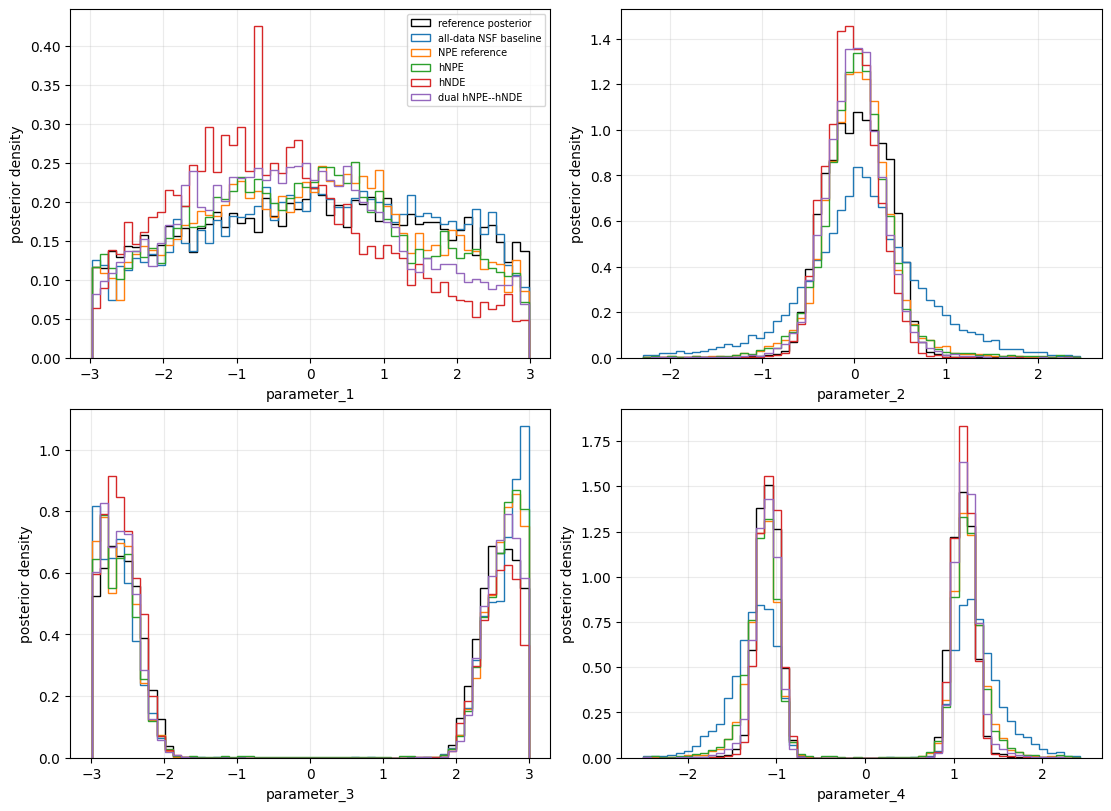

In [11]:
reference_samples = (
    task.get_reference_posterior_samples(num_observation=NUM_OBSERVATION)
    .detach().cpu().numpy()
)
parameter_labels = task.get_labels_parameters()

if task.dim_parameters == 2:
    methods = [
        "all-data NSF baseline",
        "NPE reference",
        "hNPE",
        "hNDE",
        "dual hNPE--hNDE",
    ]
    panels = [("reference posterior", reference_samples)] + [
        (method, posterior_draws.samples[method]) for method in methods
    ]
    n_columns = 3
    n_rows = int(np.ceil(len(panels) / n_columns))
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(4.1 * n_columns, 3.8 * n_rows),
        squeeze=False, constrained_layout=True,
    )
    combined = np.concatenate([values for _, values in panels], axis=0)
    x_range = np.quantile(combined[:, 0], [0.002, 0.998])
    y_range = np.quantile(combined[:, 1], [0.002, 0.998])
    for ax, (title, values) in zip(axes.flat, panels):
        ax.hist2d(
            values[:, 0], values[:, 1], bins=65,
            range=[x_range, y_range], cmap="Blues", cmin=1,
        )
        ax.set(title=title, xlabel=parameter_labels[0], ylabel=parameter_labels[1])
    for ax in axes.flat[len(panels):]:
        ax.set_visible(False)
else:
    n_dimensions = min(4, task.dim_parameters)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    for dimension, ax in enumerate(axes.flat[:n_dimensions]):
        combined = np.concatenate(
            [
                reference_samples[:, dimension],
                posterior_draws.samples["all-data NSF baseline"][:, dimension],
                posterior_draws.samples["hNPE"][:, dimension],
                posterior_draws.samples["hNDE"][:, dimension],
            ]
        )
        low, high = np.quantile(combined, [0.002, 0.998])
        bins = np.linspace(low, high, 55)
        ax.hist(
            reference_samples[:, dimension], bins=bins, density=True,
            histtype="step", color="black", lw=2, label="reference posterior",
        )
        for method, style in [
            ("all-data NSF baseline", "--"),
            ("NPE reference", ":"),
            ("hNPE", "-"),
            ("hNDE", "-."),
            ("dual hNPE--hNDE", "-"),
        ]:
            ax.hist(
                posterior_draws.samples[method][:, dimension],
                bins=bins, density=True, histtype="step",
                lw=1.5, ls=style, label=method,
            )
        ax.set(xlabel=parameter_labels[dimension], ylabel="posterior density")
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=7)

export_exercise10_figure(fig, "observation1_posterior_closure_conditionalref_v3")
plt.show()


### Optional posterior-predictive check

A posterior-predictive check needs fresh simulator calls. It is therefore disabled by default and is never folded into the official 100,000-call benchmark result. If enabled, the cell reports the extra call count explicitly and must be treated as a separate diagnostic campaign.


In [12]:
if RUN_POSTERIOR_PREDICTIVE:
    predictive_diagnostics = posterior_predictive_diagnostics(
        task,
        posterior_draws.samples[HEADLINE_METHOD],
        observation.detach().cpu().numpy(),
        n_simulations=2_000,
        seed=SEED + 800,
    )
    display(predictive_diagnostics.style.format(precision=4).hide(axis="index"))
    print("These 2,000 calls are diagnostic and are outside the official training budget.")
else:
    print(
        "Posterior-predictive simulation is disabled: the headline campaign "
        f"still uses exactly {NUM_SIMULATIONS:,} simulator calls."
    )


Posterior-predictive simulation is disabled: the headline campaign still uses exactly 100,000 simulator calls.


## 8. Paper comparison over all ten observations

The paper metric is the mean z-scored, five-fold C2ST over ten fixed
observations. Every route remains visible: the all-data NSF baseline,
cross-fitted NPE reference, hNPE, conditional-reference hNDE, and the
fixed geometric dual consensus.

The result table now retains per-observation ESS, maximum normalized
weight, and Pareto-$\hat k$. A low mean C2ST is not accepted as a healthy
result if it is supported by a collapsed or pathological importance
tail.


In [13]:
suite_results, _ = evaluate_observation_suite(
    hybrid_models,
    baseline_model=baseline_model,
    observations=OBSERVATIONS,
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 900,
    keep_draws=False,
)
suite_results["profile"] = PROFILE
suite_results["run_tag"] = RUN_TAG
suite_results["flow_architecture"] = "lu_mixed_nsf_v2"
suite_results["hnde_reference"] = "conditional_q_eta_x_given_theta"

result_path = RESULT_DIR / f"{TASK_NAME}_{RUN_TAG}_c2st.csv"
suite_results.to_csv(result_path, index=False)
print("Saved:", result_path)
display(
    summarize_our_results(suite_results)
    .style.format({"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"})
    .hide(axis="index")
)

weight_health = suite_results.loc[
    suite_results["algorithm"].isin(
        ["hNPE", "hNDE", "dual hNPE--hNDE"]
    ),
    [
        "num_observation",
        "algorithm",
        "ESS",
        "ESS_fraction",
        "max_weight_fraction",
        "pareto_k",
    ],
]
display(
    weight_health.sort_values(["num_observation", "algorithm"])
    .style.format(precision=4)
    .hide(axis="index")
)



Evaluating official observation 1

Evaluating official observation 2

Evaluating official observation 3

Evaluating official observation 4

Evaluating official observation 5

Evaluating official observation 6

Evaluating official observation 7

Evaluating official observation 8

Evaluating official observation 9

Evaluating official observation 10
Saved: exercise10_benchmark_results/slcp_challenge_budget100000_lu8_k5_ratioensemble4_conditionalref_v3_c2st.csv


task,num_simulations,algorithm,mean,std,count,ci95
slcp,100000,dual hNPE--hNDE,0.6103,0.0429,10,0.0266
slcp,100000,hNDE,0.6361,0.0986,10,0.0611
slcp,100000,NPE reference,0.7135,0.0550,10,0.0341
slcp,100000,hNPE,0.7144,0.0550,10,0.0341
slcp,100000,all-data NSF baseline,0.8133,0.0481,10,0.0298


num_observation,algorithm,ESS,ESS_fraction,max_weight_fraction,pareto_k
1,dual hNPE--hNDE,160909.7988,0.3218,0.0002,0.3218
1,hNDE,3395.9387,0.0068,0.0083,0.6571
1,hNPE,494849.8015,0.9897,0.0000,0.1043
2,dual hNPE--hNDE,104304.5406,0.2086,0.0005,0.3908
2,hNDE,634.1623,0.0013,0.0227,0.7674
2,hNPE,495880.5997,0.9918,0.0000,0.2558
3,dual hNPE--hNDE,194554.5757,0.3891,0.0002,0.3407
3,hNDE,4806.8477,0.0096,0.0077,0.6154
3,hNPE,496657.3657,0.9933,0.0000,0.3196
4,dual hNPE--hNDE,143564.0994,0.2871,0.0002,0.3447


Wrote standalone figure script: exercise10_figures_scripts/slcp/challenge_budget100000_lu8_k5_ratioensemble4_conditionalref_v3/paper_leaderboard_conditionalref_v3.py


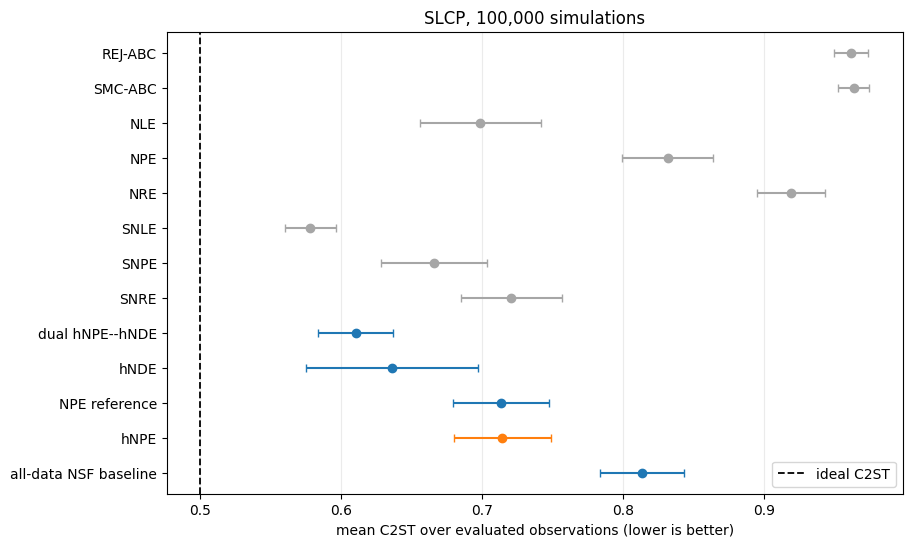

task,num_simulations,algorithm,mean,std,count,ci95,best_published_algorithm,best_published_mean,best_published_ci95,delta_C2ST,beats_published_mean
slcp,100000,hNPE,0.7144,0.0550,10,0.0341,SNLE,0.5781,0.0182,0.1363,False


The best published mean has not yet been beaten on this task.


In [14]:
paper_task = summarize_paper_results(
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    task=TASK_NAME,
)
ours_task = summarize_our_results(suite_results)

fig, ax = plt.subplots(figsize=(9.5, 6.0))
paper_order = list(PAPER_ALGORITHMS)
paper_plot = paper_task.set_index("algorithm").reindex(paper_order).dropna().reset_index()
our_plot = ours_task.sort_values("mean")
labels = list(paper_plot["algorithm"]) + list(our_plot["algorithm"])
means = np.concatenate([paper_plot["mean"], our_plot["mean"]])
errors = np.concatenate([paper_plot["ci95"], our_plot["ci95"].fillna(0.0)])
colors = ["0.65"] * len(paper_plot) + [
    "C1" if algorithm == HEADLINE_METHOD else "C0"
    for algorithm in our_plot["algorithm"]
]
y = np.arange(len(labels))
for yi, mean, error, color in zip(y, means, errors, colors):
    ax.errorbar(mean, yi, xerr=error, fmt="o", color=color, capsize=3)
ax.axvline(0.5, color="black", ls="--", lw=1.3, label="ideal C2ST")
ax.set(
    yticks=y,
    yticklabels=labels,
    xlabel="mean C2ST over evaluated observations (lower is better)",
    title=f"{task.name_display}, {NUM_SIMULATIONS:,} simulations",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.legend()
export_exercise10_figure(fig, "paper_leaderboard_conditionalref_v3")
plt.show()

comparison = compare_with_paper(
    suite_results,
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    headline_method=HEADLINE_METHOD,
)
display(comparison.style.format(precision=4).hide(axis="index"))

if len(OBSERVATIONS) < 10:
    print(
        "Diagnostic only: the paper averages over ten observations. "
        "Use PROFILE='paper' or 'challenge' for a headline comparison."
    )
elif bool(comparison["beats_published_mean"].iloc[0]):
    print("The predeclared hNPE headline beats the best published mean C2ST.")
else:
    print("The best published mean has not yet been beaten on this task.")


## 9. Two-task campaign: Two Moons and SLCP

Each task is trained and cached separately because the fivefold dual campaign is expensive. Run this notebook once for Two Moons and once for SLCP. The cell below reads only v2 result files and never averages them with the earlier defective-flow run.

SLCP is intentionally subjected to the same large hNPE and hNDE ensembles. Its five-dimensional, four-mode posterior makes it a reach target, but also a much stronger test of whether the dual construction remains useful beyond the two-dimensional diagnostic.


In [15]:
saved_result_files = sorted(
    RESULT_DIR.glob("*_conditionalref_v3_c2st.csv")
)
if saved_result_files:
    all_our_results = pd.concat(
        [pd.read_csv(path) for path in saved_result_files],
        ignore_index=True,
    )
    all_our_results = all_our_results.loc[
        all_our_results["task"].isin(BENCHMARK_TASKS)
        & (all_our_results["run_tag"] == RUN_TAG)
    ]
    campaign_summary = summarize_our_results(all_our_results)
    display(
        campaign_summary.style.format(
            {"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"}
        ).hide(axis="index")
    )
    completed_tasks = set(all_our_results["task"])
    missing_tasks = [
        name for name in BENCHMARK_TASKS if name not in completed_tasks
    ]
    print(
        "Loaded", len(saved_result_files),
        "conditional-reference v3 campaign file(s)."
    )
    if missing_tasks:
        print("Still to run:", ", ".join(missing_tasks))
    else:
        print(
            "Both Two Moons and SLCP conditional-reference campaigns "
            "are complete."
        )
else:
    print("No conditional-reference v3 result files were found yet.")


task,num_simulations,algorithm,mean,std,count,ci95
slcp,100000,dual hNPE--hNDE,0.6103,0.0429,10,0.0266
slcp,100000,hNDE,0.6361,0.0986,10,0.0611
slcp,100000,NPE reference,0.7135,0.0550,10,0.0341
slcp,100000,hNPE,0.7144,0.0550,10,0.0341
slcp,100000,all-data NSF baseline,0.8133,0.0481,10,0.0298
two_moons,100000,hNDE,0.5063,0.0104,10,0.0065
two_moons,100000,dual hNPE--hNDE,0.5064,0.0101,10,0.0062
two_moons,100000,NPE reference,0.5096,0.0124,10,0.0077
two_moons,100000,hNPE,0.5110,0.0140,10,0.0087
two_moons,100000,all-data NSF baseline,0.5497,0.0366,10,0.0227


Loaded 2 conditional-reference v3 campaign file(s).
Both Two Moons and SLCP conditional-reference campaigns are complete.


## Conclusions and limitations

This v3 notebook replaces the unconditional observation reference by
conditional-reference hNDE:

$$
p(x\mid\theta)
=
q_\eta(x\mid\theta)
\frac{c(x,\theta)}{Z_{\rm C}(\theta)}.
$$

The flow now performs the same kind of density-estimation work as NLE,
while the classifier learns only a residual. The dual construction
keeps its scientific advantages, but $q_\eta(x_o\mid\theta)$ must remain
inside posterior and evidence integrals.

The notebook also fixes the paired train/validation leakage and makes
five diagnostics first-class outputs: conditional-flow C2ST,
parameter-dependent normalization, member-wise ratio tails, per-fold
ESS, and per-observation Pareto-$\hat k$.

The 100,000-simulation comparison remains amortized. It does not add
observation-specific sequential rounds, so SNLE retains an allocation
advantage on SLCP. The purpose of this rerun is to test whether a
classifier-corrected conditional likelihood closes the gap without
changing the simulator budget.
